# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


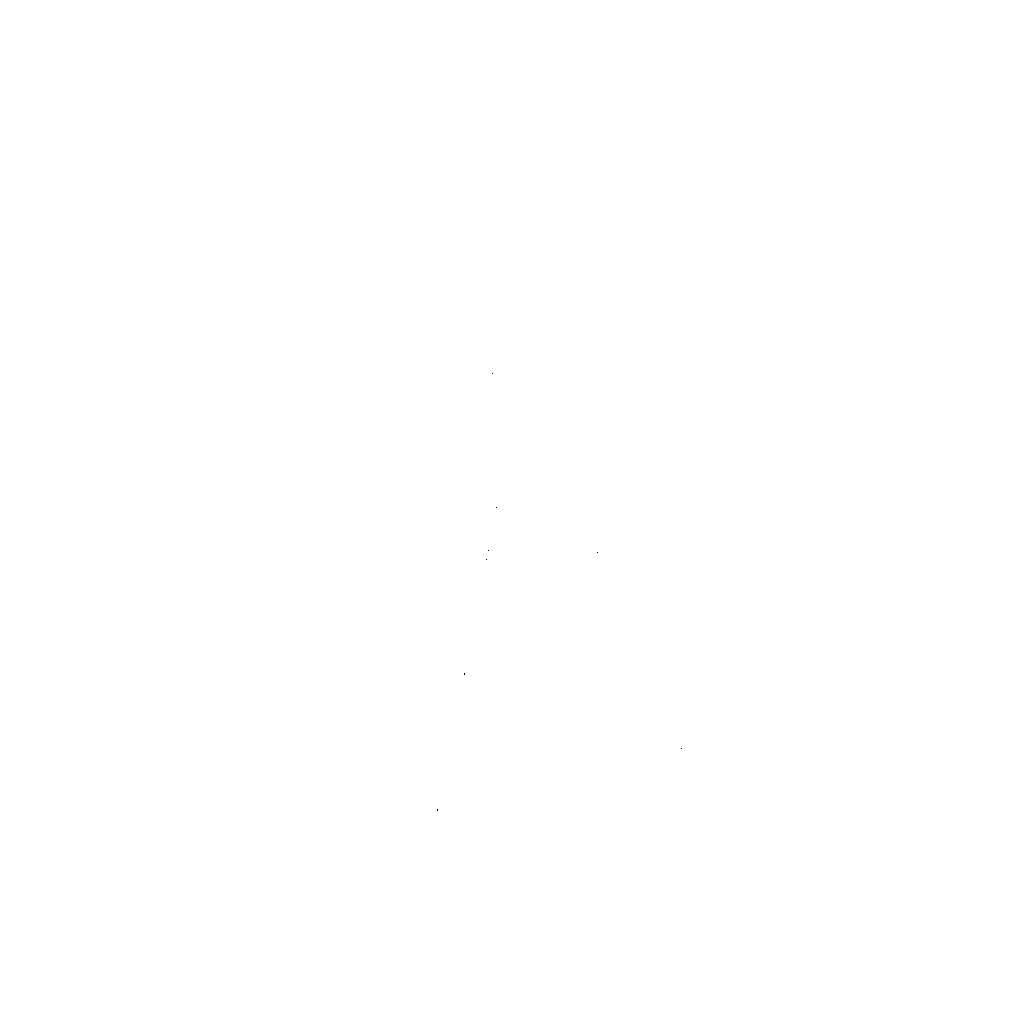

Threshold value: 50


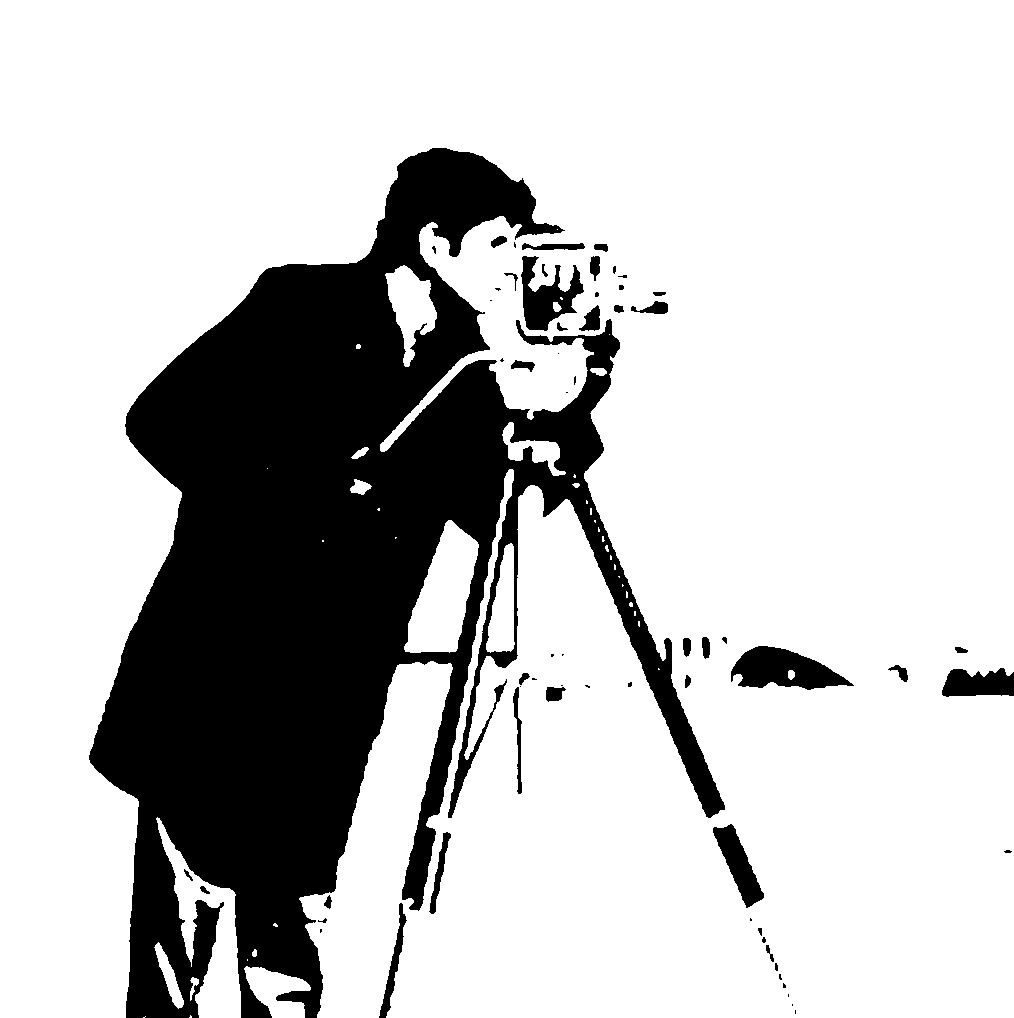

Threshold value: 100


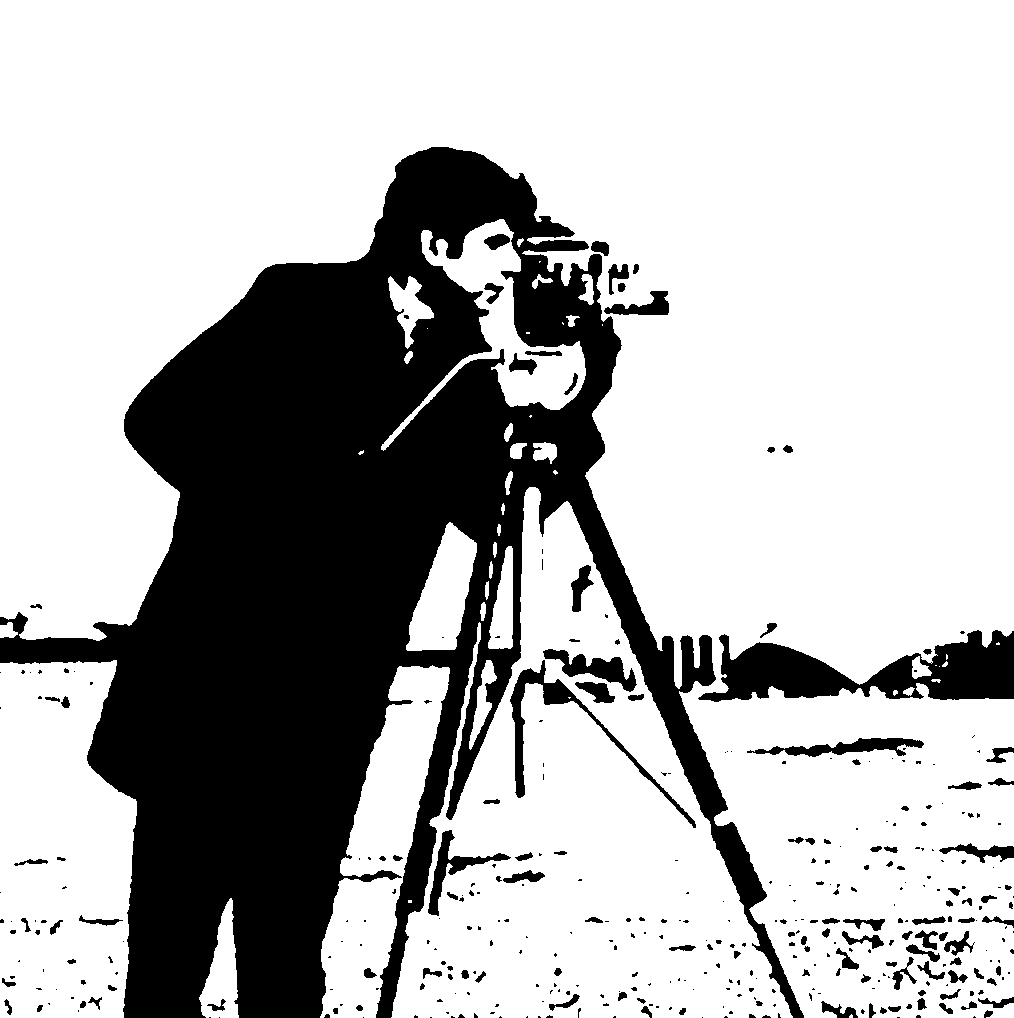

Threshold value: 150


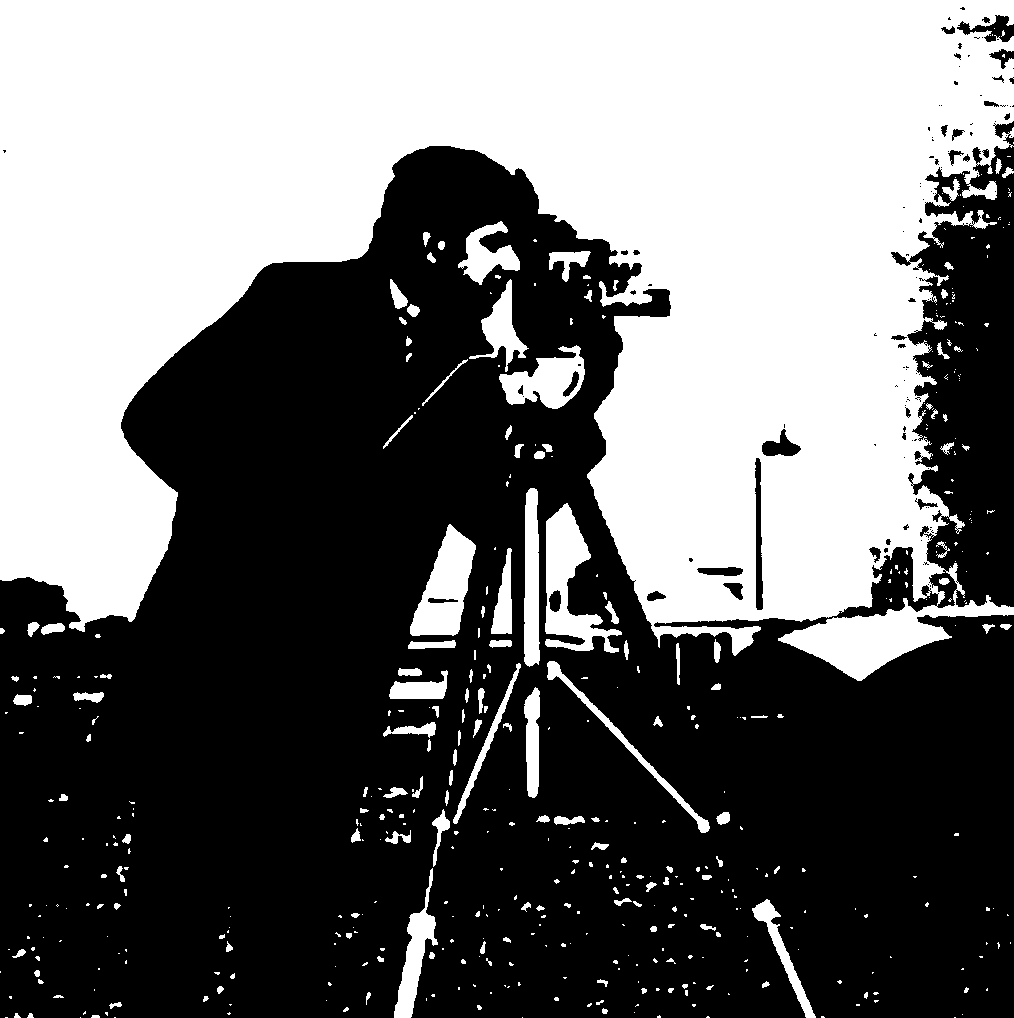

Threshold value: 200


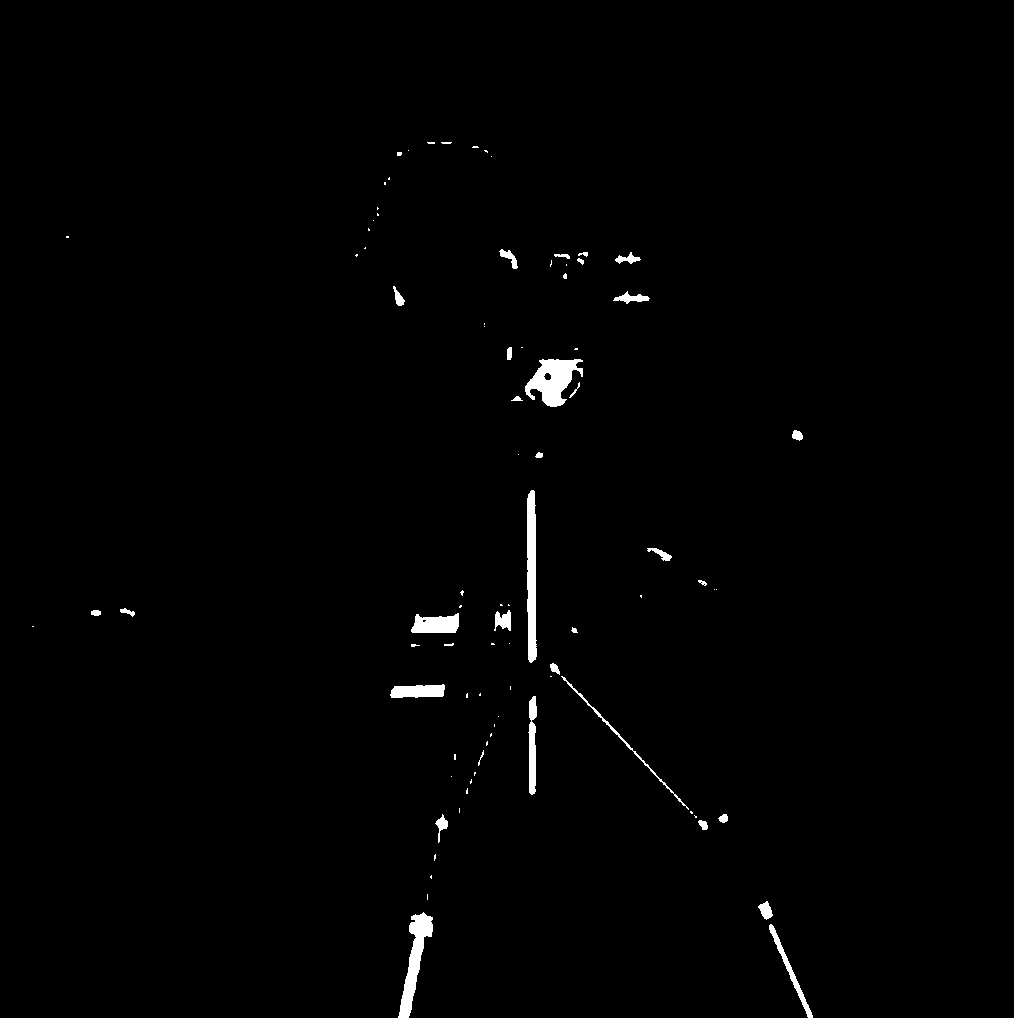

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


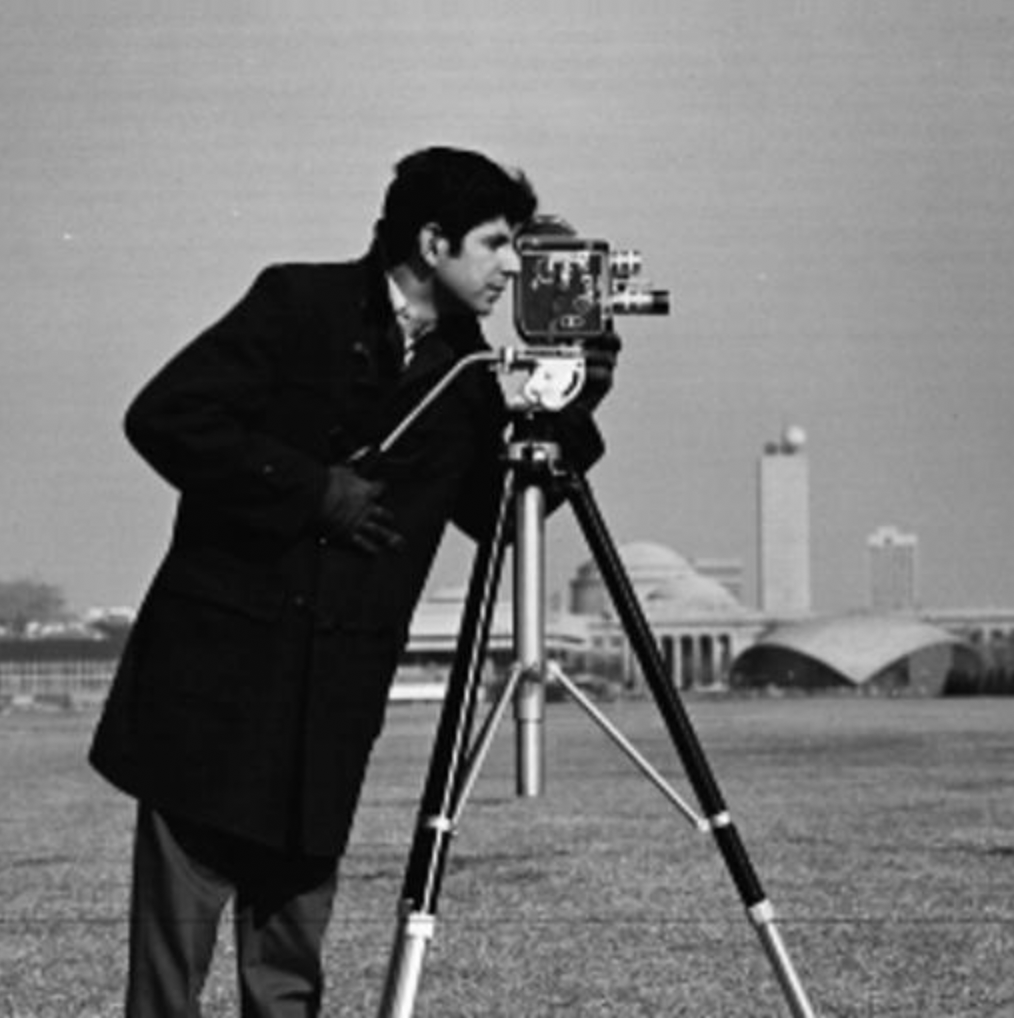

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

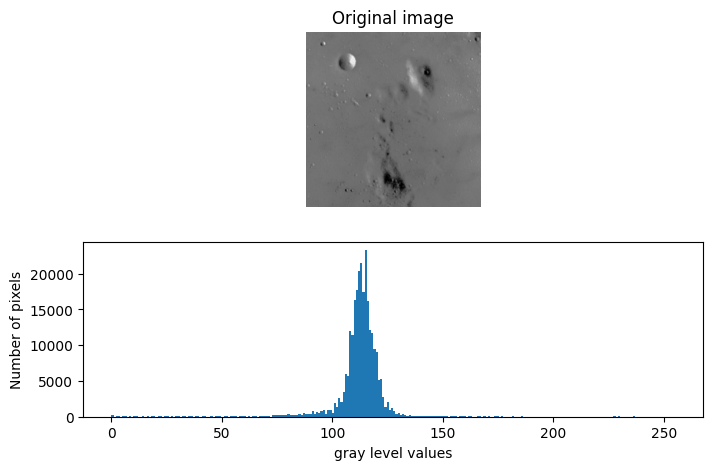

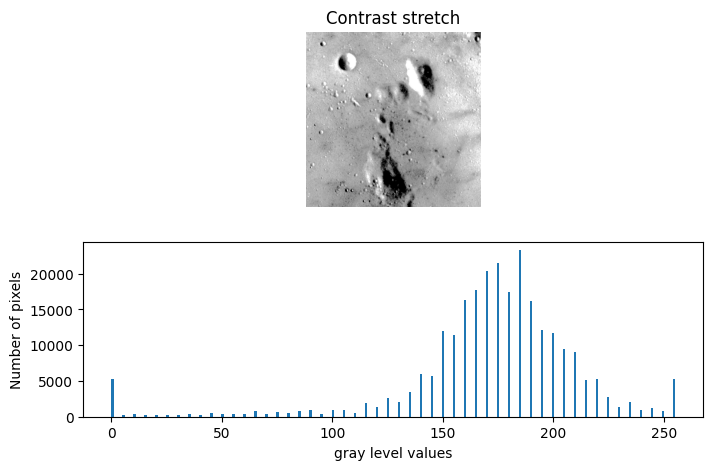

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


### Task 1
 Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

In [1]:
# Step#1: Load necessary libraries
from skimage import data
from skimage import exposure
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity
p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

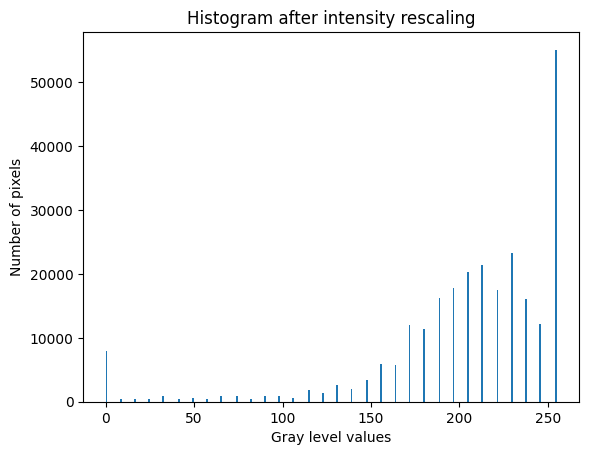

In [2]:
# Plot histogram of the rescaled image
plt.hist(img_rescale.flatten(), bins=256, range=(0, 255))
plt.xlabel("Gray level values")
plt.ylabel("Number of pixels")
plt.title("Histogram after intensity rescaling")
plt.show()

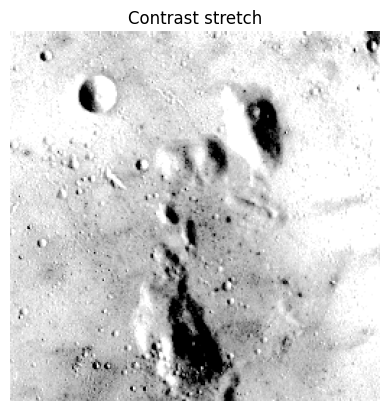

In [3]:
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')
plt.show()

### Task 2
Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram

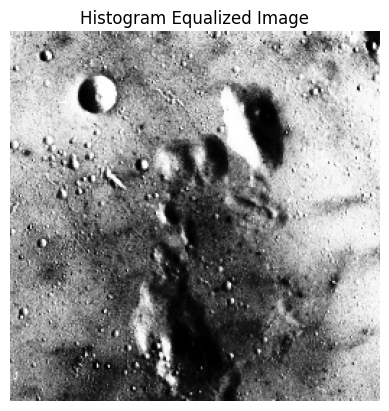

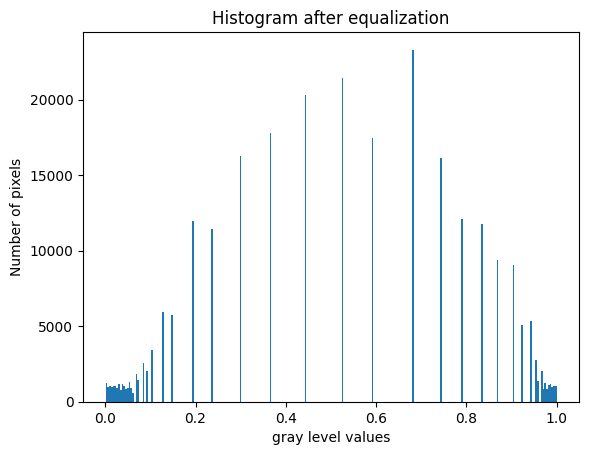

In [9]:
# Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Load moon image
img = data.moon()

# Histogram equalization
image_equalized = exposure.equalize_hist(img)

# Display equalized image
plt.imshow(image_equalized, cmap = 'gray')
plt.axis('off')
plt.title('Histogram Equalized Image')
plt.show()

# Plot histogram
plt.hist(image_equalized.flatten(), bins = 256)
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after equalization')
plt.show()

### Task 3
Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching

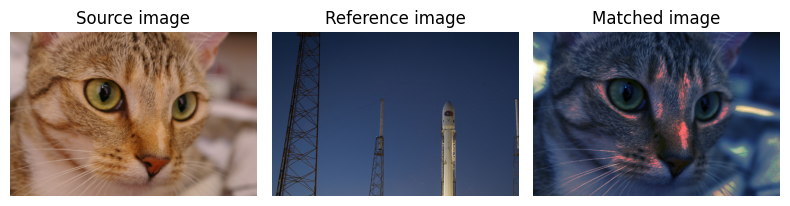

In [13]:
rocket_image = data.rocket()
chelsea_image = data.chelsea()

image_matching = exposure.match_histograms(chelsea_image, rocket_image, channel_axis=-1)
#                                         (image        , reference, channel_axis=None, multichannel=False)
# channel_axis=-1 --> the last dimension contains the color channels (R, G, B)



fig, (ax1, ax2, ax3) = plt.subplots(nrows=1,
                                    ncols=3,
                                    figsize=(8, 3),
                                    sharex=True,
                                    sharey=True)
for aa in (ax1, ax2, ax3):
    aa.set_axis_off()

# displaying images
ax1.imshow(chelsea_image)
ax1.set_title('Source image')

ax2.imshow(rocket_image)
ax2.set_title('Reference image')

ax3.imshow(image_matching)
ax3.set_title('Matched image')

plt.tight_layout()
plt.show()

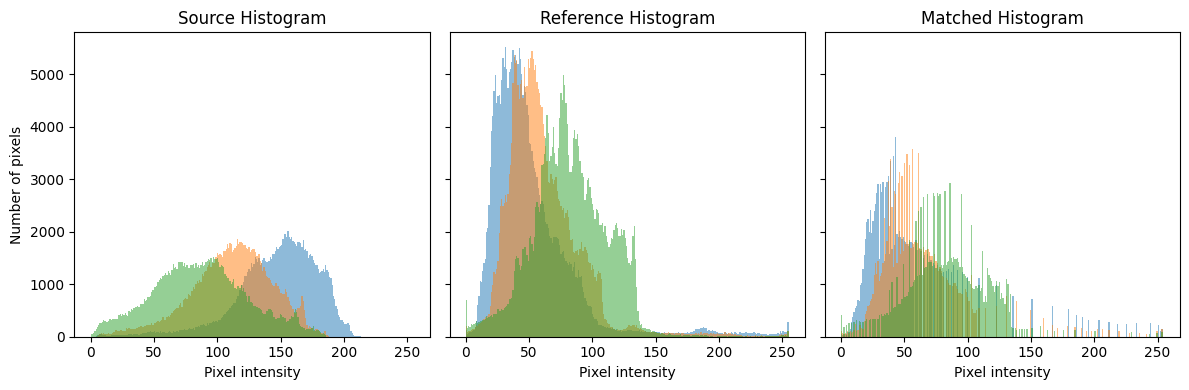

In [14]:
# Plot histograms of source, reference, and matched images

fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

# Source image histogram
for channel in range(3):
    ax1.hist(
        chelsea_image[:, :, channel].flatten(),
        bins=256,
        range=(0, 255),
        alpha=0.5
    )

ax1.set_title("Source Histogram")
ax1.set_xlabel("Pixel intensity")
ax1.set_ylabel("Number of pixels")


# Reference image histogram
for channel in range(3):
    ax2.hist(
        rocket_image[:, :, channel].flatten(),
        bins=256,
        range=(0, 255),
        alpha=0.5
    )

ax2.set_title("Reference Histogram")
ax2.set_xlabel("Pixel intensity")


# Matched image histogram
for channel in range(3):
    ax3.hist(
        image_matching[:, :, channel].flatten(),
        bins=256,
        range=(0, 255),
        alpha=0.5
    )

ax3.set_title("Matched Histogram")
ax3.set_xlabel("Pixel intensity")

plt.tight_layout()
plt.show()